# Jalen Brunson Shot Selection Prediction

## Problem Framing
This project was made out of the interest of the NBA playoffs. By the time designing this project, the New York Knicks and the Cleveland Cavaliers are advancing to the Eastern Conference Finals. With that, I have deciced to create a prediction model on New York Knicks' starting point guard, Jalen Brunson.

The goal of this project is to predict whether Jalen Brunson makes or misses a shot based on shot location, shot type, shot zone, and game context.

The target variable is `SHOT_MADE_FLAG`, where:
- 1 = made shot
- 0 = missed shot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Circle, Rectangle, Arc

from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

import xgboost as xgb
from xgboost import XGBClassifier

## Data Collection

In [2]:
# Finding Jalen Brunson's player ID

nba_players = players.get_players()

player_name = "Jalen Brunson"

player_id = next(
    (
        player['id']
        for player in nba_players
        if player['full_name'].lower() == player_name.lower()
    ),
    None
)

print("Jalen Brunson's Id", player_id)

Jalen Brunson's Id 1628973


In [3]:
# Creating Jalen Brunson Shot Selection Dataframe
shot_chart = shotchartdetail.ShotChartDetail(
    player_id=1628973, 
    team_id=0,       
    context_measure_simple='FGA', # <-- CHANGE THIS FROM 'FGM' TO 'FGA'
    season_nullable='2024-25',
    season_type_all_star='Regular Season'
)

# Convert to a pandas dataframe
shot_df = shot_chart.get_data_frames()[0]

## Data Cleaning & Feature Engineering

In [4]:
# Now your SHOT_MADE_FLAG column will show both 1 (make) and 0 (miss)
JB_shot_selection_df = shot_df[['EVENT_TYPE', 'SHOT_MADE_FLAG', 'LOC_X','LOC_Y',
                                 'SHOT_TYPE','SHOT_ZONE_BASIC','SHOT_ZONE_AREA',
                                 'SHOT_ZONE_RANGE','SHOT_DISTANCE','MINUTES_REMAINING','SECONDS_REMAINING','HTM','VTM']]

# Making home/away column
JB_shot_selection_df['Home_Court'] = np.where(JB_shot_selection_df['HTM'] == "NYK", 'Home', 'Away') 
JB_shot_selection_df['Opp'] = np.where(JB_shot_selection_df['HTM'] != "NYK", JB_shot_selection_df['HTM'], JB_shot_selection_df['VTM'])

# Droping HTM and VTM
JB_shot_selection_df = JB_shot_selection_df.drop(columns=['HTM', 'VTM'])

# Creating a shot angle
JB_shot_selection_df['SHOT_ANGLE'] = np.arctan2(
    JB_shot_selection_df['LOC_Y'],
    JB_shot_selection_df['LOC_X']
)

JB_shot_selection_df['CLUTCH_TIME'] = (JB_shot_selection_df['MINUTES_REMAINING'] <= 1).astype(int)

JB_shot_selection_df

/var/folders/70/58_fmkvx1rv29ckl5tw1vyb00000gn/T/ipykernel_32921/3460354688.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  JB_shot_selection_df['Home_Court'] = np.where(JB_shot_selection_df['HTM'] == "NYK", 'Home', 'Away')
/var/folders/70/58_fmkvx1rv29ckl5tw1vyb00000gn/T/ipykernel_32921/3460354688.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  JB_shot_selection_df['Opp'] = np.where(JB_shot_selection_df['HTM'] != "NYK", JB_shot_selection_df['HTM'], JB_shot_selection_df['VTM'])


,EVENT_TYPE,SHOT_MADE_FLAG,LOC_X,LOC_Y,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,MINUTES_REMAINING,SECONDS_REMAINING,Home_Court,Opp,SHOT_ANGLE,CLUTCH_TIME
0,Missed Shot,0,-4,52,2PT Field Goal,In The Paint (Non-RA),Center(C),Less Than 8 ft.,5,9,53,Away,PHI,1.647568,0
1,Missed Shot,0,-178,233,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,29,8,31,Away,PHI,2.223165,0
2,Missed Shot,0,-104,143,2PT Field Goal,Mid-Range,Left Side Center(LC),16-24 ft.,17,6,14,Away,PHI,2.199593,0
3,Missed Shot,0,28,10,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,2,5,49,Away,PHI,0.343024,0
4,Missed Shot,0,229,5,3PT Field Goal,Right Corner 3,Right Side(R),24+ ft.,22,3,32,Away,PHI,0.021831,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Made Shot,1,-124,224,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,25,8,3,Away,ORL,2.076377,0
1196,Missed Shot,0,93,234,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,25,6,31,Away,ORL,1.192502,0
1197,Made Shot,1,-6,24,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,2,6,7,Away,ORL,1.815775,0
1198,Missed Shot,0,118,279,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,30,3,12,Away,ORL,1.170673,0


In [5]:
# Checking the dataframe for JB shot selection
print(JB_shot_selection_df.info())
print(JB_shot_selection_df.head())
print(JB_shot_selection_df.describe())
print(JB_shot_selection_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EVENT_TYPE         1200 non-null   object 
 1   SHOT_MADE_FLAG     1200 non-null   int64  
 2   LOC_X              1200 non-null   int64  
 3   LOC_Y              1200 non-null   int64  
 4   SHOT_TYPE          1200 non-null   object 
 5   SHOT_ZONE_BASIC    1200 non-null   object 
 6   SHOT_ZONE_AREA     1200 non-null   object 
 7   SHOT_ZONE_RANGE    1200 non-null   object 
 8   SHOT_DISTANCE      1200 non-null   int64  
 9   MINUTES_REMAINING  1200 non-null   int64  
 10  SECONDS_REMAINING  1200 non-null   int64  
 11  Home_Court         1200 non-null   object 
 12  Opp                1200 non-null   object 
 13  SHOT_ANGLE         1200 non-null   float64
 14  CLUTCH_TIME        1200 non-null   int64  
dtypes: float64(1), int64(7), object(7)
memory usage: 140.8+ KB
None
    EVEN

## Exploratory Data Analysis

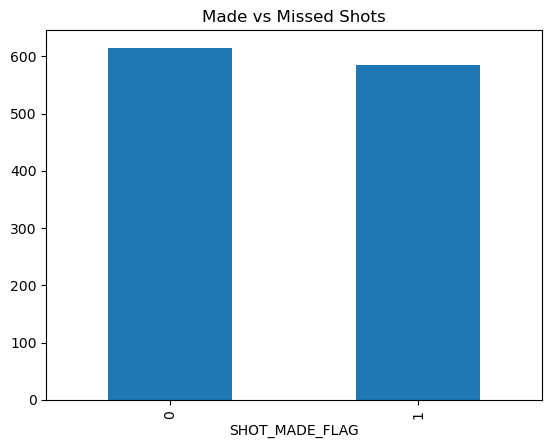

In [6]:
JB_shot_selection_df['SHOT_MADE_FLAG'].value_counts().plot(kind='bar')
plt.title('Made vs Missed Shots')
plt.show()

In [7]:
JB_shot_selection_df

,EVENT_TYPE,SHOT_MADE_FLAG,LOC_X,LOC_Y,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,MINUTES_REMAINING,SECONDS_REMAINING,Home_Court,Opp,SHOT_ANGLE,CLUTCH_TIME
0,Missed Shot,0,-4,52,2PT Field Goal,In The Paint (Non-RA),Center(C),Less Than 8 ft.,5,9,53,Away,PHI,1.647568,0
1,Missed Shot,0,-178,233,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,29,8,31,Away,PHI,2.223165,0
2,Missed Shot,0,-104,143,2PT Field Goal,Mid-Range,Left Side Center(LC),16-24 ft.,17,6,14,Away,PHI,2.199593,0
3,Missed Shot,0,28,10,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,2,5,49,Away,PHI,0.343024,0
4,Missed Shot,0,229,5,3PT Field Goal,Right Corner 3,Right Side(R),24+ ft.,22,3,32,Away,PHI,0.021831,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Made Shot,1,-124,224,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,25,8,3,Away,ORL,2.076377,0
1196,Missed Shot,0,93,234,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,25,6,31,Away,ORL,1.192502,0
1197,Made Shot,1,-6,24,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,2,6,7,Away,ORL,1.815775,0
1198,Missed Shot,0,118,279,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,30,3,12,Away,ORL,1.170673,0


In [8]:
# Cleaning data
JB_shot_selection_df = JB_shot_selection_df.drop_duplicates()
JB_shot_selection_df = JB_shot_selection_df.dropna()

# Fixing time (Finding total seconds)
JB_shot_selection_df['TOTAL_SECONDS_REMAINING'] = (
    JB_shot_selection_df['MINUTES_REMAINING'] * 60 
    + JB_shot_selection_df['SECONDS_REMAINING']
)

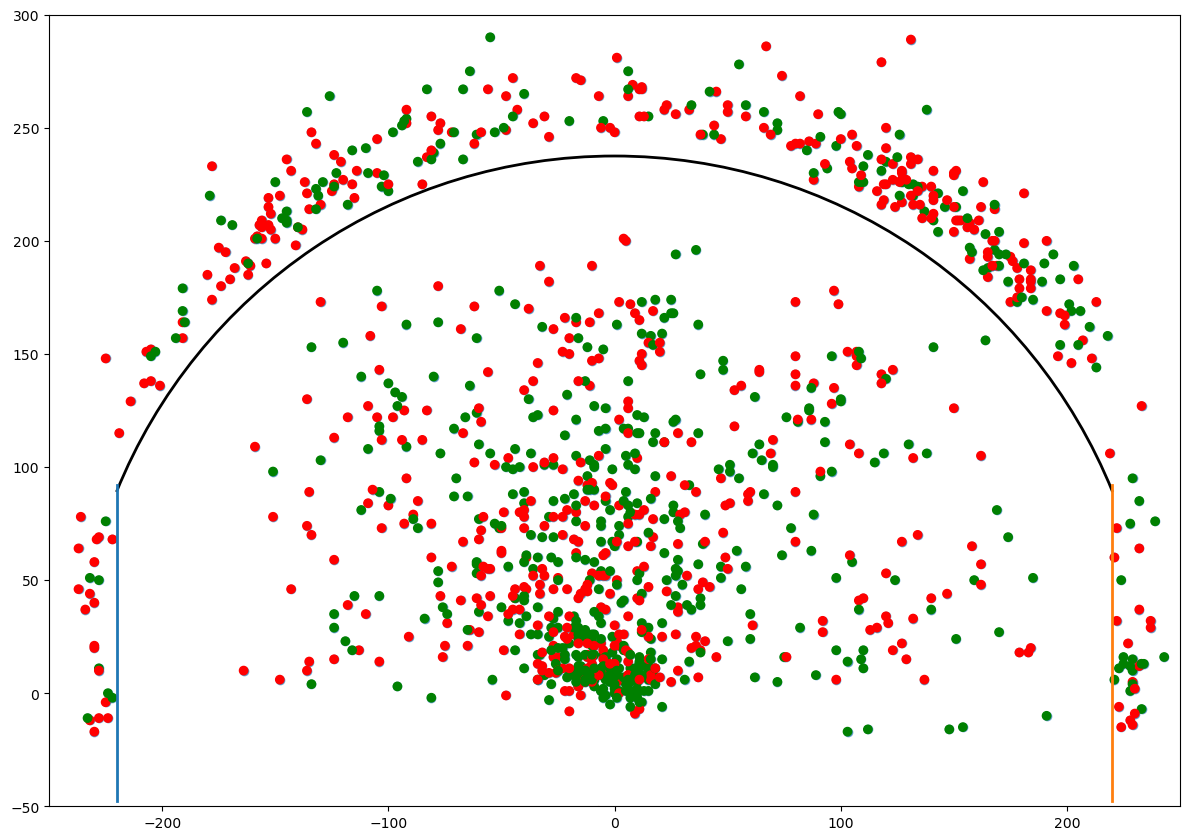

In [9]:
x = JB_shot_selection_df['LOC_X']
y = JB_shot_selection_df['LOC_Y']
z = JB_shot_selection_df['SHOT_MADE_FLAG']
fig, ax = plt.subplots(figsize=(12, 11))

# Scatter plot
ax.scatter(x, y, alpha=0.6)

# Draw 3PT Line 

# Corner 3 lines
ax.plot([-220, -220], [-47.5, 92], linewidth=2)
ax.plot([220, 220], [-47.5, 92], linewidth=2)

# 3PT arc
three_arc = Arc(
    (0, 0),           # center
    475, 475,         # width and height
    theta1=22,        # starting angle
    theta2=158,       # ending angle
    linewidth=2
)

ax.add_patch(three_arc)

# To make it look like a court
ax.set_xlim(-250, 250)
ax.set_ylim(-50, 300)

ax.set_aspect('equal')

# Create a color list based on a condition
colors = np.where(z > 0.5, 'green', 'red')

plt.scatter(x, y, c=colors)

plt.tight_layout()
plt.show()

## Model Training

In [10]:
features = ['LOC_X',
    'LOC_Y',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'SHOT_DISTANCE'
]

target = 'SHOT_MADE_FLAG'

# Create dataframe copy
JB_shot_selection_df_copy = JB_shot_selection_df.copy()

# Encode categorical variables
categorical_cols = [
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE'
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    JB_shot_selection_df_copy[col] = le.fit_transform(JB_shot_selection_df_copy[col])
    label_encoders[col] = le

# X and y
X = JB_shot_selection_df_copy[features]
y = JB_shot_selection_df_copy[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=62
)

# Build model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=62
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy for training:", accuracy)

Accuracy for training: 0.5458333333333333


In [11]:
learning_rate_range = np.arange(0.01, 1, 0.05)

test_XG = []
train_XG = []

for lr in learning_rate_range:

    xgb_classifier = xgb.XGBClassifier(
        learning_rate=lr,
        n_estimators=100,
        max_depth=2,
        random_state=62,
        eval_metric='logloss'
    )

    xgb_classifier.fit(X_train, y_train)

    train_score = xgb_classifier.score(X_train, y_train)
    test_score = xgb_classifier.score(X_test, y_test)

    train_XG.append(train_score)
    test_XG.append(test_score)

    print(f"lr={lr:.2f} | train={train_score:.4f} | test={test_score:.4f}")

lr=0.01 | train=0.6010 | test=0.5708
lr=0.06 | train=0.6365 | test=0.5292
lr=0.11 | train=0.6542 | test=0.5417
lr=0.16 | train=0.6740 | test=0.5625
lr=0.21 | train=0.6844 | test=0.5667
lr=0.26 | train=0.7042 | test=0.5833
lr=0.31 | train=0.7083 | test=0.5833
lr=0.36 | train=0.7219 | test=0.5333
lr=0.41 | train=0.7427 | test=0.5792
lr=0.46 | train=0.7417 | test=0.5583
lr=0.51 | train=0.7552 | test=0.5458
lr=0.56 | train=0.7458 | test=0.5792
lr=0.61 | train=0.7531 | test=0.5417
lr=0.66 | train=0.7438 | test=0.5625
lr=0.71 | train=0.7583 | test=0.5833
lr=0.76 | train=0.7740 | test=0.5542
lr=0.81 | train=0.7760 | test=0.5417
lr=0.86 | train=0.7781 | test=0.5625
lr=0.91 | train=0.7854 | test=0.5750
lr=0.96 | train=0.7802 | test=0.5667


## Model Evaluation


In [12]:
final_model = xgb.XGBClassifier(
    learning_rate=0.05,
    n_estimators=200,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    min_child_weight=3,
    eval_metric='logloss',
    random_state=62
)

final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)
final_probs = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, final_preds))
print(confusion_matrix(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, final_probs))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=62)
scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f"ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

              precision    recall  f1-score   support

           0       0.54      0.61      0.57       123
           1       0.52      0.45      0.49       117

    accuracy                           0.53       240
   macro avg       0.53      0.53      0.53       240
weighted avg       0.53      0.53      0.53       240

[[75 48]
 [64 53]]
ROC-AUC: 0.5761239663678688
ROC-AUC: 0.5584 ± 0.0147


In [13]:
validation_results = X_test.copy()
validation_results['Actual'] = y_test
validation_results['Predicted'] = final_preds
validation_results['Predicted_Make_Probability'] = final_probs

validation_results.head()

,LOC_X,LOC_Y,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,Actual,Predicted,Predicted_Make_Probability
654,-132,243,1,0,1,1,27,0,1,0.507489
72,22,62,0,1,0,3,6,1,0,0.493867
145,9,9,0,4,0,3,1,1,1,0.712048
1007,80,136,0,1,4,2,15,0,1,0.509677
2,-104,143,0,3,1,0,17,0,0,0.498320


In [14]:
standalone_model = xgb.XGBClassifier(
    learning_rate=0.05,
    n_estimators=200,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    min_child_weight=3,
    eval_metric='logloss',
    random_state=62
)

standalone_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

## Cavaliers-Specific Analysis

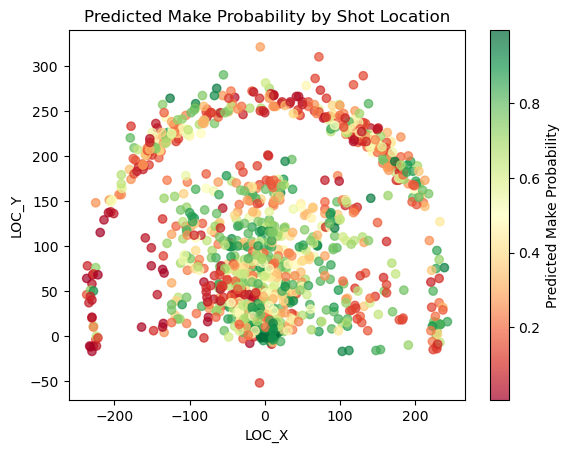

In [15]:
# Visualization for Shot Prediction

model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=62
)

model.fit(X_train, y_train)

JB_shot_selection_df['pred_prob'] = model.predict_proba(X)[:, 1]

plt.scatter(
    JB_shot_selection_df['LOC_X'],
    JB_shot_selection_df['LOC_Y'],
    c=JB_shot_selection_df['pred_prob'],
    cmap='RdYlGn',
    alpha=0.7
)

plt.colorbar(label='Predicted Make Probability')
plt.title('Predicted Make Probability by Shot Location')
plt.xlabel('LOC_X')
plt.ylabel('LOC_Y')
plt.show()

In [16]:
cavs_df = JB_shot_selection_df[
    JB_shot_selection_df['Opp'] == 'CLE'
].copy()

for col in categorical_cols:
    le = LabelEncoder()
    cavs_df[col] = le.fit_transform(cavs_df[col])

features = model.get_booster().feature_names

X_cavs = cavs_df[features]

cavs_df['pred_prob'] = model.predict_proba(X_cavs)[:, 1]

In [17]:
def draw_court(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()

    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    paint = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                     linewidth=lw, color=color)
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180,
                     linewidth=lw, color=color)
    corner_left = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_right = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158,
                    linewidth=lw, color=color)

    court_elements = [
        hoop, backboard, paint,
        free_throw, restricted,
        corner_left, corner_right,
        three_arc
    ]

    for element in court_elements:
        ax.add_patch(element)

    return ax

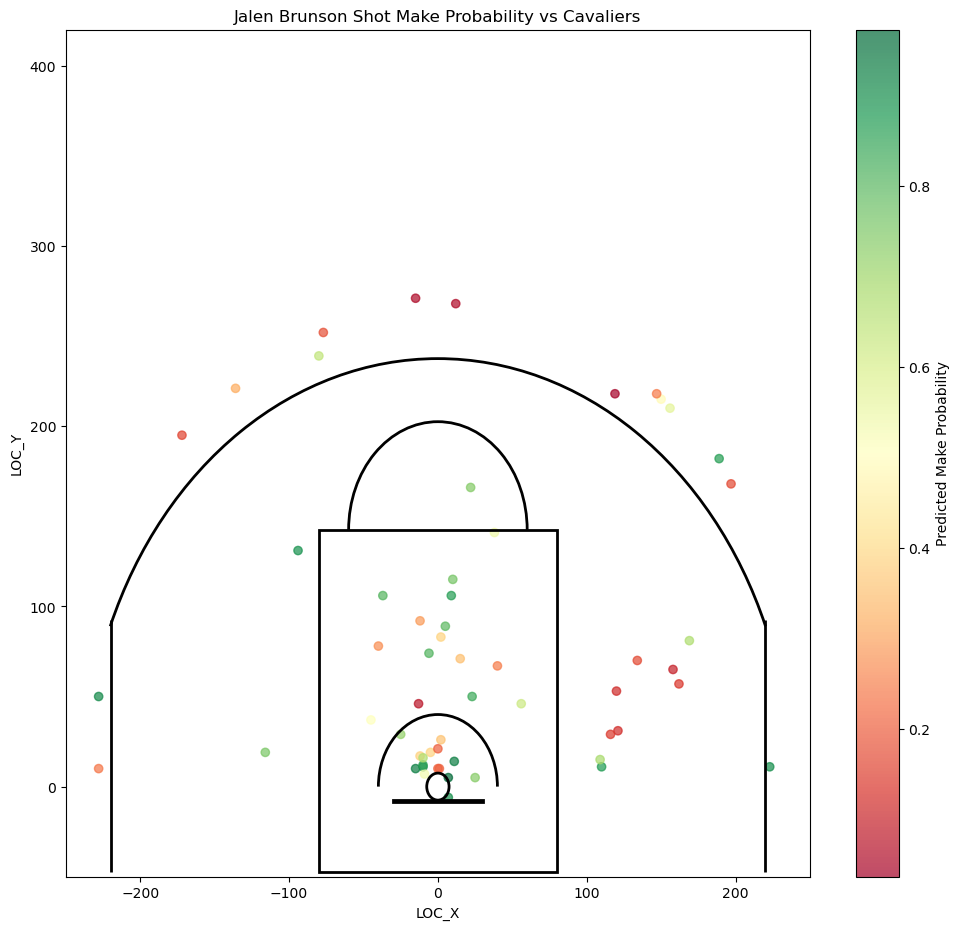

In [18]:
plt.figure(figsize=(12,11))

scatter = plt.scatter(
    cavs_df['LOC_X'],
    cavs_df['LOC_Y'],
    c=cavs_df['pred_prob'],
    cmap='RdYlGn',
    alpha=0.7
)

draw_court()

plt.xlim(-250, 250)
plt.ylim(-50, 420)

plt.colorbar(scatter, label='Predicted Make Probability')

plt.title('Jalen Brunson Shot Make Probability vs Cavaliers')
plt.xlabel('LOC_X')
plt.ylabel('LOC_Y')

plt.show()

In [19]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.5708333333333333
ROC-AUC: 0.5710166076019734


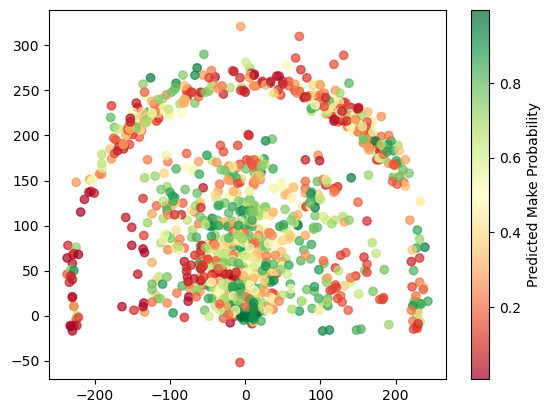

In [20]:
JB_shot_selection_df['pred_prob'] = model.predict_proba(X)[:, 1]

plt.scatter(
    JB_shot_selection_df['LOC_X'],
    JB_shot_selection_df['LOC_Y'],
    c=JB_shot_selection_df['pred_prob'],
    cmap='RdYlGn', alpha=0.7
)
plt.colorbar(label='Predicted Make Probability')

In [21]:
trees = model.get_booster().get_dump(with_stats=True)

print(trees[0])  # first tree
print(trees[1])  # second tree
print(trees[2])  # third tree

0:[SHOT_DISTANCE<2] yes=1,no=2,missing=2,gain=27.0202885,cover=239.849976
	1:[SHOT_DISTANCE<1] yes=3,no=4,missing=4,gain=2.99802208,cover=24.2348423
		3:leaf=0.47969982,cover=5.7464056
		4:[LOC_X<7] yes=7,no=8,missing=8,gain=3.77162266,cover=18.4884357
			7:[LOC_X<5] yes=13,no=14,missing=14,gain=4.92752123,cover=10.993124
				13:[LOC_Y<6] yes=23,no=24,missing=24,gain=1.0960691,cover=9.74390507
					23:leaf=-0.0583536364,cover=1.2492187
					24:[LOC_Y<13] yes=37,no=38,missing=38,gain=0.725553989,cover=8.49468708
						37:leaf=0.257359207,cover=5.7464056
						38:leaf=0.051023338,cover=2.748281
				14:leaf=-0.325112939,cover=1.2492187
			8:[LOC_Y<0] yes=15,no=16,missing=16,gain=0.757954597,cover=7.49531174
				15:leaf=0.0750260204,cover=1.2492187
				16:leaf=0.406253338,cover=6.24609327
	2:[SHOT_DISTANCE<18] yes=5,no=6,missing=6,gain=14.2337246,cover=215.615143
		5:[LOC_X<-132] yes=9,no=10,missing=10,gain=5.96683216,cover=129.419052
			9:leaf=-0.390162647,cover=1.99874985
			10:[LOC_Y<95

In [22]:
model_df = JB_shot_selection_df.copy()


features = [
    'LOC_X',
    'LOC_Y',
    'SHOT_DISTANCE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'Home_Court',
    'Opp',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING'
]

X = model_df[features]
y = model_df['SHOT_MADE_FLAG']

In [23]:
numeric_features = [
    'LOC_X',
    'LOC_Y',
    'SHOT_DISTANCE',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING'
]

categorical_features = [
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'Home_Court',
    'Opp'
]

features = numeric_features + categorical_features

X = JB_shot_selection_df[features]
y = JB_shot_selection_df['SHOT_MADE_FLAG']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=62,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', xgb.XGBClassifier(
            max_depth=2,
            n_estimators=100,
            learning_rate=0.05,
            eval_metric='logloss',
            random_state=62
        ))
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE',
                                                   'Home_Court', 'Opp']),
                                                 ('num', 'passthrough',
                                                  ['LOC_X', 'LOC_Y',
                                                   'SHOT_DISTANCE',
                                                   'MINUTES_REMAINING',
                                                   'SECONDS_REMAINING'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, ca...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [24]:
features = [
    'LOC_X',
    'LOC_Y',
    'SHOT_DISTANCE',
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING'
]

target = 'SHOT_MADE_FLAG'

model_df = JB_shot_selection_df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

numeric_features = [
    'LOC_X',
    'LOC_Y',
    'SHOT_DISTANCE',
    'MINUTES_REMAINING',
    'SECONDS_REMAINING'
]

categorical_features = [
    'SHOT_TYPE',
    'SHOT_ZONE_BASIC',
    'SHOT_ZONE_AREA',
    'SHOT_ZONE_RANGE'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=62
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=62,
    stratify=y
)

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)
probs = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

Accuracy: 0.5791666666666667
ROC-AUC: 0.6267806267806268
              precision    recall  f1-score   support

           0       0.59      0.60      0.59       123
           1       0.57      0.56      0.56       117

    accuracy                           0.58       240
   macro avg       0.58      0.58      0.58       240
weighted avg       0.58      0.58      0.58       240



ROC-AUC was used because shot prediction is a probabilistic binary classification problem, and accuracy alone may not fully capture model performance.

In [25]:
# Cavs-only data
cavs_df = JB_shot_selection_df[
    JB_shot_selection_df['Opp'] == 'CLE'
].copy()

X_cavs = cavs_df[features]
y_cavs = cavs_df['SHOT_MADE_FLAG']

X_train_cavs, X_test_cavs, y_train_cavs, y_test_cavs = train_test_split(
    X_cavs,
    y_cavs,
    test_size=0.2,
    random_state=62,
    stratify=y_cavs
)

cavs_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', xgb.XGBClassifier(
            max_depth=2,
            n_estimators=10,
            learning_rate=0.05,
            eval_metric='logloss',
            random_state=62
        ))
    ]
)

cavs_model.fit(X_train_cavs, y_train_cavs)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE']),
                                                 ('num', 'passthrough',
                                                  ['LOC_X', 'LOC_Y',
                                                   'SHOT_DISTANCE',
                                                   'MINUTES_REMAINING',
                                                   'SECONDS_REMAINING'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=10, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [26]:
xgb_model = cavs_model.named_steps['model']

cavs_trees = xgb_model.get_booster().get_dump(with_stats=True)

feature_names = features

for i, tree in enumerate(cavs_trees[:3]):
    readable_tree = tree

    for j, feature in enumerate(feature_names):
        readable_tree = readable_tree.replace(f"f{j}", feature)

    print(f"\nTREE {i}\n")
    print(readable_tree)


TREE 0

0:[LOC_Y7<7] yes=1,no=2,missing=2,gain=3.65316057,cover=11.413043
	1:[SHOT_DISTANCE1<6] yes=3,no=4,missing=4,gain=4.46992254,cover=5.70652151
		3:leaf=0.0383252464,cover=1.24054813
		4:leaf=-0.0477260947,cover=4.46597338
	2:[LOC_Y7<116] yes=5,no=6,missing=6,gain=3.30156708,cover=5.70652151
		5:leaf=0.0515106693,cover=3.47353506
		6:leaf=-0.0171466172,cover=2.23298669


TREE 1

0:[LOC_Y7<7] yes=1,no=2,missing=2,gain=3.34251332,cover=11.4055309
	1:[SHOT_DISTANCE1<6] yes=3,no=4,missing=4,gain=4.17977428,cover=5.68920422
		3:leaf=0.0372013934,cover=1.2442354
		4:leaf=-0.045957379,cover=4.4449687
	2:[LOC_Y7<116] yes=5,no=6,missing=6,gain=3.04763651,cover=5.71632671
		5:leaf=0.04936013,cover=3.48682904
		6:leaf=-0.0165728088,cover=2.22949743


TREE 2

0:[LOC_Y7<7] yes=1,no=2,missing=2,gain=3.06034946,cover=11.3881874
	1:[SHOT_DISTANCE1<6] yes=3,no=4,missing=4,gain=3.91108465,cover=5.6670866
		3:leaf=0.0361252166,cover=1.24695289
		4:leaf=-0.0442886055,cover=4.42013359
	2:[SHOT_DISTA

In [27]:
bst = model.get_booster()

# Print feature importance
for importance_type in ['weight', 'gain', 'cover', 'total_gain', 'total_cover']:
    print(f"{importance_type}:")
    print(bst.get_score(importance_type=importance_type))
    print()

weight:
{'f0': 2.0, 'f1': 1.0, 'f2': 3.0, 'f3': 15.0, 'f4': 1.0, 'f5': 14.0, 'f6': 8.0, 'f7': 3.0, 'f8': 11.0, 'f9': 20.0, 'f10': 7.0, 'f11': 11.0, 'f12': 15.0, 'f13': 23.0, 'f15': 8.0, 'f16': 1.0, 'f17': 458.0, 'f18': 442.0, 'f19': 197.0, 'f20': 235.0, 'f21': 456.0}

gain:
{'f0': 1.0011930465698242, 'f1': 3.4927728176116943, 'f2': 2.9296247959136963, 'f3': 2.5619637966156006, 'f4': 1.0244202613830566, 'f5': 2.2434065341949463, 'f6': 5.758852005004883, 'f7': 3.1766815185546875, 'f8': 1.958292841911316, 'f9': 2.1711437702178955, 'f10': 1.796363115310669, 'f11': 2.1483712196350098, 'f12': 2.2268776893615723, 'f13': 2.5942625999450684, 'f15': 1.913394808769226, 'f16': 3.036665439605713, 'f17': 2.5287764072418213, 'f18': 2.6718478202819824, 'f19': 3.6340625286102295, 'f20': 2.4886374473571777, 'f21': 2.6216654777526855}

cover:
{'f0': 3.8485960960388184, 'f1': 18.745752334594727, 'f2': 38.5629768371582, 'f3': 89.78449249267578, 'f4': 7.447536945343018, 'f5': 88.6016616821289, 'f6': 53.0691

In [28]:
xgb_model = cavs_model.named_steps['model']

cavs_trees = xgb_model.get_booster().get_dump(with_stats=True)

for i, tree in enumerate(cavs_trees[:3]):

    readable_tree = tree

    for j, feature in enumerate(features):
        readable_tree = readable_tree.replace(f"f{j}", feature)

    print(f"TREE {i}")

    print(readable_tree)

TREE 0
0:[LOC_Y7<7] yes=1,no=2,missing=2,gain=3.65316057,cover=11.413043
	1:[SHOT_DISTANCE1<6] yes=3,no=4,missing=4,gain=4.46992254,cover=5.70652151
		3:leaf=0.0383252464,cover=1.24054813
		4:leaf=-0.0477260947,cover=4.46597338
	2:[LOC_Y7<116] yes=5,no=6,missing=6,gain=3.30156708,cover=5.70652151
		5:leaf=0.0515106693,cover=3.47353506
		6:leaf=-0.0171466172,cover=2.23298669

TREE 1
0:[LOC_Y7<7] yes=1,no=2,missing=2,gain=3.34251332,cover=11.4055309
	1:[SHOT_DISTANCE1<6] yes=3,no=4,missing=4,gain=4.17977428,cover=5.68920422
		3:leaf=0.0372013934,cover=1.2442354
		4:leaf=-0.045957379,cover=4.4449687
	2:[LOC_Y7<116] yes=5,no=6,missing=6,gain=3.04763651,cover=5.71632671
		5:leaf=0.04936013,cover=3.48682904
		6:leaf=-0.0165728088,cover=2.22949743

TREE 2
0:[LOC_Y7<7] yes=1,no=2,missing=2,gain=3.06034946,cover=11.3881874
	1:[SHOT_DISTANCE1<6] yes=3,no=4,missing=4,gain=3.91108465,cover=5.6670866
		3:leaf=0.0361252166,cover=1.24695289
		4:leaf=-0.0442886055,cover=4.42013359
	2:[SHOT_DISTANCE0<9

In [29]:
# More in depth

cavs_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', xgb.XGBClassifier(
            max_depth=4,
            n_estimators=50,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0,
            eval_metric='logloss',
            random_state=62
        ))
    ]
)

cavs_model.fit(X_train_cavs, y_train_cavs)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SHOT_TYPE',
                                                   'SHOT_ZONE_BASIC',
                                                   'SHOT_ZONE_AREA',
                                                   'SHOT_ZONE_RANGE']),
                                                 ('num', 'passthrough',
                                                  ['LOC_X', 'LOC_Y',
                                                   'SHOT_DISTANCE',
                                                   'MINUTES_REMAINING',
                                                   'SECONDS_REMAINING'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsam...
                               feature_types=None, feature_weights=None,
                               gamma=0, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=50,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [30]:
xgb_model = cavs_model.named_steps['model']

cavs_trees = xgb_model.get_booster().get_dump(with_stats=True)

for i, tree in enumerate(cavs_trees[:5]):
    print("=" * 50)
    print(f"TREE {i}")
    print("=" * 50)
    print(tree)

TREE 0
0:[f17<7] yes=1,no=2,missing=2,gain=3.65316057,cover=11.413043
	1:[f21<6] yes=3,no=4,missing=4,gain=4.46992254,cover=5.70652151
		3:leaf=0.0383252464,cover=1.24054813
		4:[f18<50] yes=7,no=8,missing=8,gain=0.281707764,cover=4.46597338
			7:leaf=-0.0562975295,cover=2.97731566
			8:leaf=-0.0148499822,cover=1.48865783
	2:[f17<116] yes=5,no=6,missing=6,gain=3.30156708,cover=5.70652151
		5:[f20<4] yes=9,no=10,missing=10,gain=0.133366108,cover=3.47353506
			9:leaf=0.0655146241,cover=1.48865783
			10:leaf=0.0225775801,cover=1.98487711
		6:leaf=-0.0171466172,cover=2.23298669

TREE 1
0:[f17<7] yes=1,no=2,missing=2,gain=3.40289783,cover=11.404932
	1:[f21<6] yes=3,no=4,missing=4,gain=4.19819927,cover=5.69134235
		3:leaf=0.0372013934,cover=1.2442354
		4:[f18<50] yes=7,no=8,missing=8,gain=0.258159637,cover=4.44710684
			7:leaf=-0.0544268601,cover=2.96045136
			8:leaf=-0.0144177275,cover=1.48665547
	2:[f17<116] yes=5,no=6,missing=6,gain=3.08546066,cover=5.71359015
		5:[f20<4] yes=9,no=10,miss

In [31]:
print(len(cavs_df))
print(cavs_df['SHOT_MADE_FLAG'].value_counts())

58
SHOT_MADE_FLAG
0    31
1    27
Name: count, dtype: int64


# Model Interpretation/Summary #

**The XGBoost classifier has an accuracy of 57.9% and a ROC-AUC score of 0.627 when predicting whether or not Jalen Brunson's shots will go in. While shot prediction remains difficult due to randomness and missing context of the games, such as defender proximity and offensive play structure, the model demonstrated meaningful predictive capability. The balanced precision and recall scores indicate that the classifier learned stable shot-selection patterns rather than overfitting toward made or missed shots**

**The XGBoost decision trees reveal that the shot distance was the most influence feature in predicting Jalen Brunson's success in making a shot from the field. Almost every tree began by splitting on SHOT_DISTANCE, showing how the distance of the basket strongly impacts expected field goal percentage. This can be given due to the distance of a basket increasing the difficulty of a shot for most of NBA players int he league.**

The Cavs-specific XGBoost model consistently split on SHOT_ZONE_BASIC, indicating that shot zone was the dominant predictor of Brunson’s scoring efficiency against Cleveland. The repeated use of this feature across multiple boosted trees suggests that certain areas of the court produced significantly different outcomes against the Cavaliers’ defensive scheme.
Outside of the shot distance, 


Analysis of the XGBoost decision trees revealed that shot distance was the most influential feature in predicting Jalen Brunson’s shot success. Nearly every tree began by splitting on SHOT_DISTANCE, demonstrating that proximity to the basket strongly impacts expected field goal percentage. The model also incorporated spatial court positioning through LOC_X, suggesting that shot angle and floor location further influence shot quality. Overall, the trees learned intuitive basketball patterns: close-range shots produce higher expected efficiency, while contested perimeter and off-angle attempts reduce scoring probability.

### Resources:
- https://xgboost.readthedocs.io/en/release_3.2.0/python/python_api.html#xgboost.XGBClassifier
- https://medium.com/@24littledino/xgboost-classification-in-python-f29cc2c50a9b
- https://medium.com/data-science-collective/steal-my-machine-learning-project-template-9af79c496dca
- https://www.kaggle.com/discussions/general/187601

In [32]:
validation_results.to_csv("jalen_brunson_shot_predictions.csv", index=False)